In [25]:
# Standard library
import os
import gc
import time
import warnings

# Numerical computing and data processing
import numpy as np
import pandas as pd
import random
from pathlib import Path
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights

# UMAP
#import umap
from tqdm import tqdm

Use UTKFace Folder only

The labels of each face image is embedded in the file name, formated like [age]_[gender]_[race]_[date&time].jpg

[age] is an integer from 0 to 116, indicating the age
[gender] is either 0 (male) or 1 (female)
[race] is an integer from 0 to 4, denoting White, Black, Asian, Indian, and Others (like Hispanic, Latino, Middle Eastern).
[date&time] is in the format of yyyymmddHHMMSSFFF, showing the date and time an image was collected to UTKFace


Looking at the data

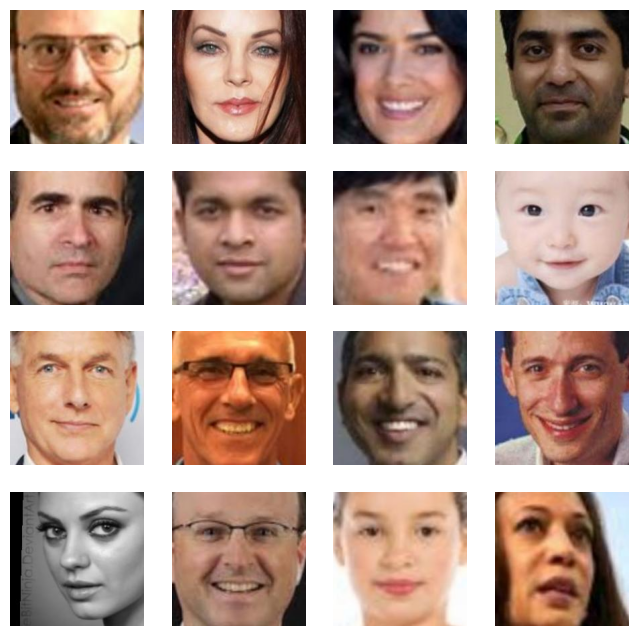

In [ ]:
img_path = Path('archive/crop_part1')
image_list = []

for filename in img_path.glob('*.jpg'):
    im = Image.open(filename)
    image_list.append(im)

random.seed(1090)
rand = random.sample(image_list, 64)

fig, axes = plt.subplots(4, 4, figsize=(8,8))

for i, ax in enumerate(axes.flat):
    if i < len(rand):
        ax.imshow(rand[i])
        ax.axis('off')
    else:
        ax.axis('off')

In [ ]:
img_path = Path("archive/UTKFace")  
age_counts = Counter()
gender_counts = Counter()
race_counts = Counter()

for f in img_path.glob("*.jpg"):
    # get filename without .jpg extension
    stem = f.stem                           # "23_0_2_20170116174525125.jpg" -> "23_0_2_20170116174525125"
    parts = stem.split("_")                # ["23", "0", "2", "20170116174525125"]

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
    except (IndexError, ValueError):
        # skip any unexpected filenames
        continue

    age_counts[age] += 1
    gender_counts[gender] += 1
    race_counts[race] += 1

print("Age distribution (age: count):")
print(dict(sorted(age_counts.items())))

print("\nGender distribution (0=male, 1=female):")
print(dict(sorted(gender_counts.items())))

print("\nRace distribution (0=White, 1=Black, 2=Asian, 3=Indian, 4=Others):")
print(dict(sorted(race_counts.items())))

total = sum(age_counts.values())
age_percent = {a: c / total * 100 for a, c in age_counts.items()}
gender_percent = {g: c / total * 100 for g, c in gender_counts.items()}
race_percent = {r: c / total * 100 for r, c in race_counts.items()}

print('')
print("Age %:", age_percent)
print("Gender %:", gender_percent)
print("Race %:", race_percent)

Age distribution (age: count):
{1: 1123, 2: 482, 3: 289, 4: 273, 5: 196, 6: 131, 7: 139, 8: 263, 9: 166, 10: 156, 11: 65, 12: 130, 13: 81, 14: 157, 15: 177, 16: 247, 17: 158, 18: 262, 19: 98, 20: 284, 21: 346, 22: 395, 23: 426, 24: 859, 25: 734, 26: 2197, 27: 615, 28: 918, 29: 570, 30: 724, 31: 350, 32: 664, 33: 143, 34: 409, 35: 880, 36: 483, 37: 293, 38: 325, 39: 265, 40: 526, 41: 132, 42: 266, 43: 157, 44: 100, 45: 440, 46: 153, 47: 170, 48: 153, 49: 148, 50: 381, 51: 138, 52: 232, 53: 241, 54: 353, 55: 268, 56: 236, 57: 97, 58: 271, 59: 82, 60: 293, 61: 159, 62: 125, 63: 103, 64: 50, 65: 259, 66: 77, 67: 94, 68: 100, 69: 56, 70: 147, 71: 33, 72: 98, 73: 63, 74: 32, 75: 148, 76: 58, 77: 28, 78: 69, 79: 23, 80: 133, 81: 22, 82: 40, 83: 18, 84: 24, 85: 155, 86: 35, 87: 10, 88: 34, 89: 33, 90: 82, 91: 2, 92: 13, 93: 5, 95: 9, 96: 17, 99: 9, 100: 11, 101: 2, 103: 1, 105: 5, 110: 5, 111: 1, 115: 3, 116: 4}

Gender distribution (0=male, 1=female):
{0: 12391, 1: 11314}

Race distribution (

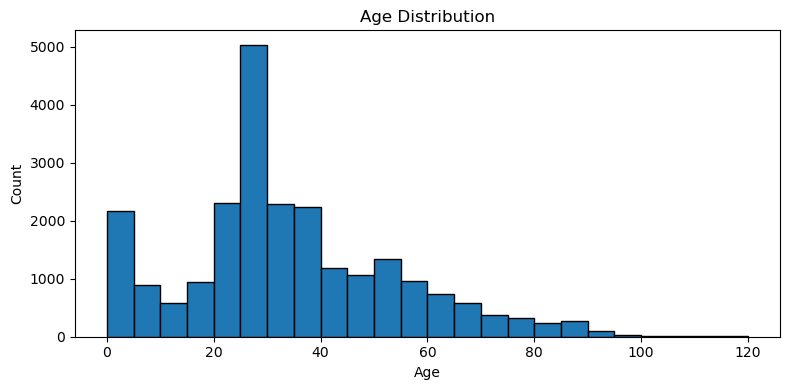

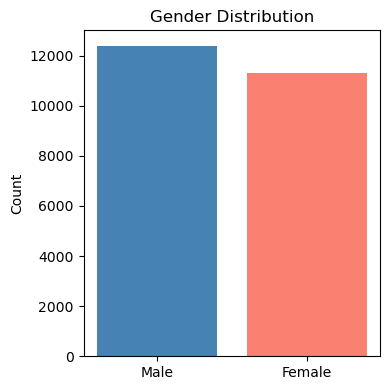

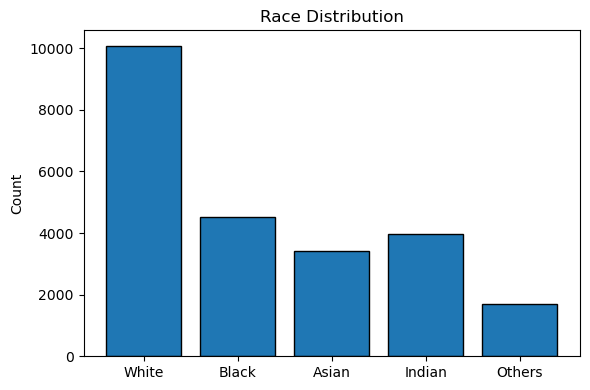

In [ ]:
ages = []
genders = []
races = []

#Collect demographic details
for f in img_path.glob("*.jpg"):
    stem = f.stem          # filename without extension
    parts = stem.split("_")

    if len(parts) < 4:
        continue  # skip weird filenames

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
    except ValueError:
        print('Error with {f}')
        continue

    ages.append(age)
    genders.append(gender)
    races.append(race)

#Age distribution 
plt.figure(figsize=(8, 4))
plt.hist(ages, bins=range(0, 121, 5), edgecolor='black')  # 0-120 in steps of 5 years
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#Gender distribution 
gender_counts = Counter(genders)
gender_labels = ['Male', 'Female']
gender_values = [gender_counts.get(0, 0), gender_counts.get(1, 0)]

plt.figure(figsize=(4, 4))
plt.bar(gender_labels, gender_values, color=['steelblue', 'salmon'])
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#Race distribution (bar plot)
race_counts = Counter(races)
race_labels_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others"
}

race_labels = [race_labels_map[i] for i in range(5)]
race_values = [race_counts.get(i, 0) for i in range(5)]

plt.figure(figsize=(6, 4))
plt.bar(race_labels, race_values, edgecolor='black')
plt.title("Race Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Racial imbalance, lack of teen faces/excess of baby faces

70/15/15 Split

In [29]:
# collect all file paths
file_list = list(img_path.glob('*.jpg'))

# first split: train vs temp (val+test)
train_files, temp_files = train_test_split(
    file_list, test_size=0.3, random_state=42, shuffle=True
)

# second split: val vs test (half of temp each -> 15%/15% if above is 30%)
val_files, test_files = train_test_split(
    temp_files, test_size=0.5, random_state=42, shuffle=True
)

train_images = [Image.open(f) for f in train_files]
val_images   = [Image.open(f) for f in val_files]
test_images  = [Image.open(f) for f in test_files]

print(f'Train size: {len(train_files)}')
print(f'Validation size: {len(val_files)}')
print(f'Test size: {len(test_files)}')

Train size: 16595
Validation size: 3556
Test size: 3557


First Pass ResNet CNN

First Pass EfficientNet CNN